# Lean-34b — FairBot par le théorème de Löb : coopérer parce que la coopération est prouvable

**Navigation** : [Index](README.md) | [<< Lean-34 (Calculabilité et limites)](Lean-34-Calculabilite-et-Limites.ipynb) | [GameTheory-06e (transparence des programmes)](../../GameTheory/GameTheory-06e-Open-Source-Game-Theory.ipynb) | [Prolongement : Capstone Serre 100](Lean-37-Capstone-Serre100.ipynb)

Deux programmes jouent un dilemme du prisonnier en un coup, et chacun peut lire le code source de l'autre avant de jouer. FairBot applique une règle simple : **je coopère si je peux prouver que tu coopères avec moi**. Face à sa propre copie, cette règle tourne en rond : chaque FairBot attend une preuve au sujet de l'autre, qui l'attend lui-même. On pourrait croire que la boucle ne se referme jamais. Le théorème de Löb la referme, et elle se referme sur la coopération.

Ce notebook approfondit la fin de [Lean-34](Lean-34-Calculabilite-et-Limites.ipynb), qui énonçait le théorème de Löb et le lemme diagonal. Il les **applique** au dilemme du prisonnier, sur trois niveaux de formalisation :

| Niveau | Où | Ce que « prouvable » y signifie | Statut du théorème de Löb |
|---|---|---|---|
| Témoin syntaxique | [GameTheory-06e](../../GameTheory/GameTheory-06e-Open-Source-Game-Theory.ipynb), `FairBot_toy` | la source adverse contient la chaîne `return "C"` | absent |
| L2 | `game_theory_lean/ProgramGames/FairBot.lean` | une modalité abstraite `box` | **champ postulé** `loeb` de l'interface `ModalProvability` |
| L3 | `formal_logic_lean/FormalLogic/FairBotLoeb.lean` | la prouvabilité dans une théorie arithmétique (`𝗣𝗔`), au sens de la bibliothèque *Formalized Formal Logic* (FFL) | **théorème** `ProvabilityAbstraction.löb_theorem` |

Le notebook exécute le premier niveau, explique pourquoi le deuxième a besoin de postuler Löb, fait vérifier les énoncés du troisième par le noyau Lean, puis recalcule les mêmes issues avec un petit évaluateur de logique modale écrit en Python.

**Objectifs d'apprentissage**

1. Distinguer une coopération fondée sur la syntaxe (reconnaître une chaîne) d'une coopération fondée sur la prouvabilité.
2. Comprendre pourquoi le théorème de Löb, et non les seules conditions de dérivabilité D1 à D3, force la coopération de FairBot avec lui-même.
3. Lire les énoncés Lean du module `FormalLogic.FairBotLoeb` et auditer leurs axiomes.
4. Calculer l'issue d'un duel entre agents modaux sur un cadre de Kripke de la logique GL, et la confronter aux théorèmes certifiés.

**Prérequis** : [Lean-34](Lean-34-Calculabilite-et-Limites.ipynb) (lemme diagonal, Gödel II, Löb) ; le dilemme du prisonnier en un coup ([GameTheory-06e](../../GameTheory/GameTheory-06e-Open-Source-Game-Theory.ipynb)). Le notebook tourne sous le kernel `python3` et pilote Lean dans WSL, comme Lean-34.

**Durée estimée** : 60 minutes.

**Sources primaires** (PDF hors Git, bibliographie partagée) :

- Barasz, Christiano, Fallenstein, Herreshoff, LaVictoire, Yudkowsky (2014). *Robust Cooperation in the Prisoner's Dilemma: Program Equilibrium via Provability Logic*. arXiv:1401.5577. `G:\Mon Drive\MyIA\IA\Bibliographie IA\GameTheory\2014 - Barasz et al - Robust Cooperation in the Prisoners Dilemma - Program Equilibrium via Provability Logic - arXiv 1401.5577.pdf`
- Critch (2016). *Parametric Bounded Löb's Theorem and Robust Cooperation of Bounded Agents*. arXiv:1602.04184. `G:\Mon Drive\MyIA\IA\Bibliographie IA\GameTheory\2016 - Critch - Parametric Bounded Lobs Theorem and Robust Cooperation of Bounded Agents - arXiv 1602.04184.pdf`

Les gains utilisés sont ceux de GameTheory-06e : $(C,C) \mapsto (3,3)$, $(D,D) \mapsto (1,1)$, $(C,D) \mapsto (0,5)$.

## Plan

1. **Mise en place** : localiser le lake `formal_logic_lean`, vérifier ses sources, construire le module.
2. **Le témoin syntaxique de GameTheory-06e** et ses deux échecs, calculés.
3. **Pourquoi Löb** : sur un cadre de Kripke fini, la modalité décide du nombre de points fixes de FairBot.
4. **Certification** : FairBot contre lui-même, énoncés et axiomes.
5. **Deux FairBots de codes distincts** coopèrent quand même.
6. **DefectBot, inexploitabilité et modèle standard** : ce que `𝗣𝗔` prouve, et ce qui est vrai sans être prouvé.
7. **Combat modal** : un évaluateur Python prédit les issues, et on le confronte aux théorèmes.
8. **Conclusion** : ce qui est certifié, ce qui ne l'est pas.

Trois exercices sont répartis dans les sections 5 et 7.

## 1. Mise en place : le lake `formal_logic_lean`

Le module `FormalLogic.FairBotLoeb` vit dans le lake `formal_logic_lean`, voisin de ce notebook. Ce lake consomme la bibliothèque FFL (paquet `Foundation`) à une révision épinglée par son `lake-manifest.json`. La cellule suivante :

- localise le lake : par défaut le dossier du dépôt ; la variable d'environnement `FORMAL_LOGIC_LAKE_WSL` peut désigner une **copie** sur le système de fichiers ext4 de WSL, beaucoup plus rapide à construire que `/mnt/d` ;
- dans ce cas, compare octet à octet (SHA-256) les fichiers qui déterminent le build, pour que la preuve obtenue sur la copie vaille pour le dépôt ;
- passe toute commande `lake` ou `lean` par l'organe d'exécution borné du dépôt, `scripts/lean/lean_exec.py`, qui plafonne le nombre de processus Lean de la machine et vérifie qu'aucun processus orphelin ne survit.

Aucun chemin absolu n'est affiché.

In [1]:
import hashlib
import os
import pathlib
import subprocess

NB_DIR = pathlib.Path.cwd()
REPO_LAKE = NB_DIR / "formal_logic_lean"


def wslpath(p):
    # Chemin Windows -> chemin WSL, calcule par WSL lui-meme.
    r = subprocess.run(["wsl", "-e", "wslpath", "-a", str(p).replace(chr(92), "/")],
                       capture_output=True, text=True, encoding="utf-8")
    return r.stdout.strip()


LAKE_OVERRIDE = os.environ.get("FORMAL_LOGIC_LAKE_WSL")
LAKE_DIR = LAKE_OVERRIDE or wslpath(REPO_LAKE)
LEAN_EXEC = wslpath(NB_DIR.parents[2] / "scripts" / "lean" / "lean_exec.py")


def lean_exec(commande, timeout=900):
    # Lance `commande` dans le lake via l'organe borne ; rend (code, sortie, journal de l'organe).
    r = subprocess.run(
        ["wsl", "-e", "bash", "-lc",
         f"cd {LAKE_DIR} && python3 {LEAN_EXEC} run --timeout {timeout} -- {commande}"],
        capture_output=True, text=True, encoding="utf-8", timeout=timeout + 120)
    journal = [l for l in r.stderr.splitlines() if l.startswith("[lean_exec]")]
    return r.returncode, r.stdout, journal


FICHIERS_BUILD = ["lean-toolchain", "lakefile.lean", "lake-manifest.json",
                  "FormalLogic.lean", "FormalLogic/FairBotLoeb.lean"]

print("lake utilise :", "copie ext4 (FORMAL_LOGIC_LAKE_WSL)" if LAKE_OVERRIDE
      else "formal_logic_lean du depot")
cote_wsl = subprocess.run(
    ["wsl", "-e", "bash", "-lc", f"cd {LAKE_DIR} && sha256sum " + " ".join(FICHIERS_BUILD)],
    capture_output=True, text=True, encoding="utf-8").stdout.split("\n")
empreintes_wsl = {l.split()[1]: l.split()[0] for l in cote_wsl if l.strip()}
identiques = 0
for nom in FICHIERS_BUILD:
    h_depot = hashlib.sha256((REPO_LAKE / nom).read_bytes()).hexdigest()
    h_lake = empreintes_wsl.get(nom, "absent")
    identiques += h_depot == h_lake
    print(f"  {nom:30s} depot {h_depot[:12]}  lake {h_lake[:12]}  "
          f"{'identique' if h_depot == h_lake else 'DIFFERENT'}")
print(f"{identiques}/{len(FICHIERS_BUILD)} fichiers identiques")
print((REPO_LAKE / "lean-toolchain").read_text().strip())

lake utilise : copie ext4 (FORMAL_LOGIC_LAKE_WSL)
  lean-toolchain                 depot 3aac669c7a91  lake 3aac669c7a91  identique
  lakefile.lean                  depot e89527f798fa  lake e89527f798fa  identique
  lake-manifest.json             depot c70e7f659bf5  lake c70e7f659bf5  identique
  FormalLogic.lean               depot 28f7c65c3111  lake 28f7c65c3111  identique
  FormalLogic/FairBotLoeb.lean   depot 1c14ca516e16  lake 1c14ca516e16  identique
5/5 fichiers identiques
leanprover/lean4:v4.33.1


### Lecture de la mise en place

Les cinq fichiers qui déterminent le build (toolchain, lakefile, manifeste des dépendances, racine de la bibliothèque et module étudié) ont la même empreinte SHA-256 dans le dépôt et dans le lake effectivement utilisé. Un build réussi dans ce lake vaut donc pour les sources du dépôt. La dernière ligne donne la version de Lean épinglée par le lake.

In [2]:
# Build du module etudie : incremental, rapide si les .olean sont a jour.
code_retour, sortie, journal = lean_exec("lake build FormalLogic.FairBotLoeb", timeout=5400)
utiles = [l for l in sortie.splitlines()
          if not l.startswith(("info:", "trace", "  ", "\u2139"))]
print("\n".join(utiles[-6:]))
print("\n".join(journal))
print("code de retour :", code_retour)

Build completed successfully (1225 jobs).
[lean_exec] ok exit=0 duration=3.6s orphans=0
[lean_exec] child_exit_code: 0
code de retour : 0


### Lecture du build

`lake` annonce la réussite du build, et l'organe `lean_exec` confirme un code de retour nul et **zéro processus orphelin**. Le nombre de tâches affiché compte toutes les dépendances de FFL et de Mathlib que le module importe ; seules les tâches dont les sources ont changé sont réellement recompilées.

## 2. Le témoin syntaxique de GameTheory-06e et ses deux échecs

Dans [GameTheory-06e](../../GameTheory/GameTheory-06e-Open-Source-Game-Theory.ipynb) (cellule `9b0640e6`), `FairBot_toy` coopère lorsque la source de l'adversaire **contient la chaîne** `return "C"`. Ce test syntaxique reproduit la coopération de FairBot avec lui-même, puisque sa propre source contient cette chaîne. Barasz et al. (2014, section 2) signalent pourtant deux défauts des agents qui décident sur la forme du code : ils sont fragiles face à une réécriture équivalente, et une ruse syntaxique suffit à les exploiter.

La cellule suivante reprend `FairBot_toy` à l'identique et lui oppose cinq adversaires. Chaque programme est construit **à partir de sa source** avec `exec`, ce qui garantit que le texte lu par l'adversaire est exactement le code exécuté :

- `FairBot_toy` lui-même ;
- `FairBot_guillemets`, qui applique la même règle avec des guillemets simples : il cherche `return 'C'` dans la source adverse et renvoie `'C'` ;
- `Ruse_toy`, qui contient `return "C"` dans une branche morte et joue toujours `D` ;
- `CooperateBot_toy` et `DefectBot_toy`.

In [3]:
SOURCES_TOY = {
    "FairBot_toy": (
        "def FairBot_toy(other_source):\n"
        "    if 'return \"C\"' in other_source:\n"
        "        return \"C\"\n"
        "    return \"D\""),
    "FairBot_guillemets": (
        "def FairBot_guillemets(other_source):\n"
        "    if \"return 'C'\" in other_source:\n"
        "        return 'C'\n"
        "    return 'D'"),
    "Ruse_toy": (
        "def Ruse_toy(other_source):\n"
        "    if False:\n"
        "        return \"C\"\n"
        "    return \"D\""),
    "CooperateBot_toy": "def CooperateBot_toy(_other_source):\n    return \"C\"",
    "DefectBot_toy": "def DefectBot_toy(_other_source):\n    return \"D\"",
}
BOTS_TOY = {}
for nom, src in SOURCES_TOY.items():
    espace = {}
    exec(src, espace)
    BOTS_TOY[nom] = espace[nom]

GAINS = {("C", "C"): (3, 3), ("D", "D"): (1, 1), ("C", "D"): (0, 5), ("D", "C"): (5, 0)}

print(f"{'FairBot_toy contre':20s} {'actions':8s} {'gains':8s} constat")
duels_toy = {}
for adv in SOURCES_TOY:
    a = BOTS_TOY["FairBot_toy"](SOURCES_TOY[adv])
    b = BOTS_TOY[adv](SOURCES_TOY["FairBot_toy"])
    g = GAINS[(a, b)]
    duels_toy[adv] = (a, b, g)
    constat = {"C/C": "cooperation mutuelle", "D/D": "defection mutuelle",
               "C/D": "FairBot_toy exploite", "D/C": "FairBot_toy exploite l'autre"}[f"{a}/{b}"]
    print(f"{adv:20s} {a}/{b:6s} {str(g):8s} {constat}")

# Les deux defauts, verifies :
assert duels_toy["FairBot_guillemets"][:2] == ("D", "D"), "fragilite attendue"
assert BOTS_TOY["FairBot_guillemets"](SOURCES_TOY["FairBot_guillemets"]) == "C", "copie reconnue"
assert duels_toy["Ruse_toy"][:2] == ("C", "D"), "exploitation attendue"
print("\nFragilite : meme regle, graphies differentes -> defection mutuelle ;")
print("            chacun coopere pourtant avec sa propre copie.")
print("Exploitation : Ruse_toy obtient 5 contre 0 avec une branche morte.")

FairBot_toy contre   actions  gains    constat
FairBot_toy          C/C      (3, 3)   cooperation mutuelle
FairBot_guillemets   D/D      (1, 1)   defection mutuelle
Ruse_toy             C/D      (0, 5)   FairBot_toy exploite
CooperateBot_toy     C/C      (3, 3)   cooperation mutuelle
DefectBot_toy        D/D      (1, 1)   defection mutuelle

Fragilite : meme regle, graphies differentes -> defection mutuelle ;
            chacun coopere pourtant avec sa propre copie.
Exploitation : Ruse_toy obtient 5 contre 0 avec une branche morte.


### Lecture des duels syntaxiques

Les cinq lignes montrent les deux échecs annoncés :

- **Fragilité.** `FairBot_toy` et `FairBot_guillemets` appliquent la même règle, et chacun coopère avec sa propre copie. Mais chacun cherche sa graphie dans la source de l'autre sans la trouver : l'issue est $(D, D)$, soit 1 chacun au lieu de 3. Barasz et al. relèvent ce défaut chez CliqueBot : la coopération exige une identité syntaxique que deux implémentations équivalentes n'ont pas.
- **Exploitation.** `Ruse_toy` contient `return "C"` dans une branche qui ne s'exécute jamais. `FairBot_toy` s'y laisse prendre et coopère, puis `Ruse_toy` fait défection : $(C, D)$, soit 0 pour `FairBot_toy` et 5 pour la ruse.

Le module `FairBotLoeb` traite ces deux défauts par deux théorèmes. `fairBotA_ne_fairBotB` et `pa_fairBot_pair_cooperation` établissent que deux FairBots de **codes distincts** coopèrent. `fairBot_unexploitable` établit que FairBot ne coopère que si la coopération de l'adversaire est **prouvable**, et non simplement écrite quelque part dans son code. Pour y arriver, il faut remplacer « la source contient » par « la théorie prouve », et c'est là qu'intervient le théorème de Löb.

## 3. Pourquoi Löb : combien de points fixes a FairBot contre lui-même ?

Remplaçons « la source contient `return "C"` » par « la coopération de l'adversaire est prouvable », notée $\Box$. Contre sa propre copie, FairBot coopère exactement quand il est prouvable qu'il coopère. Si $p$ désigne l'énoncé « FairBot coopère avec sa copie », sa définition se réduit à l'équation

$$p \;\leftrightarrow\; \Box p .$$

Cette équation ne dit pas encore si $p$ est vrai. Tout dépend de ce que $\Box$ sait faire. Les conditions de dérivabilité de Lean-34 en fixent trois propriétés :

- **D1** (nécessitation) : si $\varphi$ est prouvé, alors $\Box\varphi$ l'est aussi ;
- **D2** (distribution) : $\Box(\varphi \to \psi) \to (\Box\varphi \to \Box\psi)$ ;
- **D3** (introspection positive) : $\Box\varphi \to \Box\Box\varphi$.

La **sémantique de Kripke** permet de tester l'équation sans aucune arithmétique. Un cadre est un ensemble fini de mondes muni d'une relation d'accessibilité $R$ ; $\Box\varphi$ est vrai en un monde $w$ quand $\varphi$ est vrai en tout monde $v$ tel que $w\,R\,v$. D1 et D2 valent sur tout cadre. D3 vaut dès que $R$ est transitive. La cellule suivante compare trois relations transitives sur dix mondes :

| Cadre | $w$ voit $v$ quand… | Ce qu'il représente |
|---|---|---|
| identité | $v = w$ | $\Box\varphi = \varphi$ : c'est la modalité `bump p := p ∨ (0 = 1)` de L2, puisque $0 = 1$ est faux |
| ordre réflexif | $v \geq w$ | une modalité qui vérifie en plus $\Box\varphi \to \varphi$ |
| ordre strict | $v > w$ | un cadre de la logique de prouvabilité **GL** : transitif, sans chaîne ascendante infinie |

Pour chaque cadre, la cellule énumère les $2^{10} = 1024$ valuations de $p$ (une action C ou D par monde). Elle compte celles qui satisfont $p \leftrightarrow \Box p$ en tout monde, puis les instances fausses de D3 et du schéma de Löb $\Box(\Box p \to p) \to \Box p$.

In [4]:
from itertools import product

N_MONDES = 10
MONDES = range(N_MONDES)
CADRES = {
    "identite (bump)": lambda w, v: v == w,
    "ordre reflexif": lambda w, v: v >= w,
    "ordre strict (GL)": lambda w, v: v > w,
}


def boite(R, V):
    # Valeur de "boite p" en chaque monde, pour la valuation V (tuple de booleens).
    return tuple(all(V[v] for v in MONDES if R(w, v)) for w in MONDES)


def implique(a, b):
    return tuple((not x) or y for x, y in zip(a, b))


def actions(V):
    return "".join("C" if x else "D" for x in V)


VALUATIONS = list(product([False, True], repeat=N_MONDES))
bilan = {}
print(f"{'cadre':20s} {'points fixes':>13s} {'D3 fausse':>10s} {'Lob faux':>9s} {'valuations touchees':>20s}")
for nom, R in CADRES.items():
    points_fixes = [V for V in VALUATIONS if boite(R, V) == V]
    echecs_d3 = sum(not x for V in VALUATIONS
                    for x in implique(boite(R, V), boite(R, boite(R, V))))
    lob = [implique(boite(R, implique(boite(R, V), V)), boite(R, V)) for V in VALUATIONS]
    echecs_lob = sum(not x for L in lob for x in L)
    touchees = sum(not all(L) for L in lob)
    bilan[nom] = (points_fixes, echecs_d3, echecs_lob)
    print(f"{nom:20s} {len(points_fixes):13d} {echecs_d3:10d} {echecs_lob:9d} {touchees:20d}")

print("\nPoints fixes de l'ordre reflexif (monde 0 a gauche) :")
print("  " + " ".join(actions(V) for V in bilan["ordre reflexif"][0][:4]) + " ...")
print("Point fixe unique du cadre GL :", actions(bilan["ordre strict (GL)"][0][0]))

assert [len(b[0]) for b in bilan.values()] == [1024, 11, 1]
assert all(b[1] == 0 for b in bilan.values()), "D3 vaut sur les trois cadres"
assert bilan["ordre strict (GL)"][2] == 0
assert bilan["identite (bump)"][2] > 0 and bilan["ordre reflexif"][2] > 0

cadre                 points fixes  D3 fausse  Lob faux  valuations touchees
identite (bump)               1024          0      5120                 1023
ordre reflexif                  11          0      9217                 1023
ordre strict (GL)                1          0         0                    0

Points fixes de l'ordre reflexif (monde 0 a gauche) :
  DDDDDDDDDD DDDDDDDDDC DDDDDDDDCC DDDDDDDCCC ...
Point fixe unique du cadre GL : CCCCCCCCCC


### Lecture : D1 à D3 ne décident rien, Löb décide tout

- **D3 ne sépare pas les cadres.** La colonne « D3 fausse » vaut 0 sur les trois : les trois modalités satisfont D1, D2 et D3.
- **Le nombre de points fixes, lui, les sépare.** Sur l'identité, les 1024 valuations sont des solutions : l'équation ne contraint rien, et FairBot peut aussi bien coopérer que faire défection avec sa copie. Sur l'ordre réflexif, il reste 11 solutions, de la forme `D…DC…C` : la coopération commence à un monde quelconque. Sur le cadre GL, il n'en reste **qu'une**, `CCCCCCCCCC`. Le dernier monde ne voit aucun monde, donc $\Box p$ y est vrai et $p$ aussi ; la vérité remonte ensuite de monde en monde jusqu'au premier.
- **Le schéma de Löb explique cet écart.** Il est faux sur 1023 des 1024 valuations des deux premiers cadres, soit toutes sauf celle où $p$ est vrai partout, et il ne l'est jamais sur le cadre GL.

C'est la raison pour laquelle L2 ajoute le champ `loeb` à son interface `ModalProvability` au lieu de le déduire, et pourquoi il prouve `bump_loeb_fails` : la modalité `bump` satisfait D1 à D3 mais pas Löb, comme le cadre identité ci-dessus. Aucune preuve de Löb ne peut donc s'appuyer sur D1 à D3 seules. Dans GL, en revanche, l'équation $p \leftrightarrow \Box p$ n'a qu'une solution, $p = \top$. C'est un cas du théorème du point fixe de la logique de prouvabilité, qu'utilisent Barasz et al. (2014, section 4).

Il reste à savoir si la prouvabilité **réelle** dans $\mathsf{PA}$ se comporte comme le cadre GL. C'est ce qu'établit le théorème de Löb, et c'est ce que L3 démontre au lieu de le postuler.

### De L2 à L3 : ce que chaque niveau suppose

| Ingrédient | L2 : `ModalProvability` (GameTheory) | L3 : FFL (`FormalLogic.FairBotLoeb`) |
|---|---|---|
| D1 nécessitation | champ `nec` | champ `bew_def` de la structure `Provability` : tout prédicat de prouvabilité `𝔅` le satisfait par construction |
| D2 distribution | champ `dist` | `HBL2`, dans la classe `[𝔅.HBL]` |
| D3 introspection | champ `posIntros` | `HBL3`, dans la classe `[𝔅.HBL]` |
| Löb | **champ postulé** `loeb` | **théorèmes** `löb_theorem` (la règle : de `T ⊢ 𝔅 σ 🡒 σ`, tirer `T ⊢ σ`) et `formalized_löb_theorem` (le schéma, prouvé dans `T₀`) |
| Autoréférence | aucune : l'énoncé $p$ est un paramètre | `Diagonalization T₀` : le lemme diagonal construit la phrase de FairBot |
| Modalité concrète | aucune : `box : Prop → Prop` est abstraite | `T.standardProvability`, le prédicat de prouvabilité standard d'une théorie $T$ définissable par une formule $\Delta_1$ et qui contient $\mathsf{I}\Sigma_1$ |

L2 dispose de D1 à D3 et du schéma de Löb, mais n'a aucun moyen de **fabriquer** une phrase qui parle d'elle-même. Il suppose donc l'existence d'un couple d'énoncés en duel (la structure `FairBotDuel`) et déduit la coopération de Löb. L3 dispose du lemme diagonal. Il construit la phrase de FairBot, et il déduit Löb de D1 à D3 en appliquant le lemme diagonal à une phrase auxiliaire (la phrase de Kreisel, notée `𝐊 σ` dans FFL). C'est le troisième usage du lemme diagonal que Lean-34 annonçait, après Gödel I et Tarski. L'ingrédient qui manquait à L2 était **l'autoréférence**, et non une condition de dérivabilité supplémentaire.

## 4. Certification : FairBot contre sa propre copie

Dans L3, FairBot face à sa copie est une phrase arithmétique construite par le lemme diagonal. On applique ce lemme à la formule « $x$ est prouvable » : il fournit une phrase $F$, `fairBotSelf 𝔅`, telle que la théorie de base prouve $F \leftrightarrow \Box F$. On l'appelle la phrase de Henkin : elle affirme « je suis prouvable ». La preuve de coopération tient ensuite en une ligne :

1. dans l'équivalence $F \leftrightarrow \Box F$, on garde la moitié $\Box F \to F$ (`K_right`) ;
2. on la transporte de la théorie de base $T_0$ à la théorie $T$ (`WeakerThan.pbl`) ;
3. la règle de Löb transforme « $T$ prouve $\Box F \to F$ » en « $T$ prouve $F$ ».

La cellule suivante extrait du fichier `FairBotLoeb.lean` le texte exact de ces trois déclarations, pour que la preuve lue soit celle qui a été compilée.

In [5]:
import re

SOURCE_LEAN = (REPO_LAKE / "FormalLogic" / "FairBotLoeb.lean").read_text(encoding="utf-8")


def declaration(nom):
    # Texte d'une declaration du module : de son mot-cle jusqu'a la premiere ligne vide.
    m = re.search(rf"^(?:noncomputable )?(?:def|lemma|theorem) {re.escape(nom)}\b.*?(?=\n\n)",
                  SOURCE_LEAN, flags=re.M | re.S)
    return m.group(0) if m else f"-- {nom} introuvable"


for nom in ["fairBotSelf", "fairBotSelf_spec", "fairBot_self_cooperation",
            "pa_fairBot_self_cooperation"]:
    print(declaration(nom), end="\n\n")

def fairBotSelf (𝔅 : Provability T₀ T) : Sentence L :=
  fixedpoint T₀ “x. !𝔅.prov x”

lemma fairBotSelf_spec : T₀ ⊢ fairBotSelf 𝔅 🡘 𝔅 (fairBotSelf 𝔅) := by
  simpa [fairBotSelf, Provability.pr] using diag (T := T₀) “x. !𝔅.prov x”

theorem fairBot_self_cooperation [𝔅.HBL] : T ⊢ fairBotSelf 𝔅 :=
  ProvabilityAbstraction.löb_theorem (WeakerThan.pbl (K_right fairBotSelf_spec))

theorem pa_fairBot_self_cooperation :
    𝗣𝗔 ⊢ fairBotSelf 𝗣𝗔.standardProvability :=
  standard_fairBot_self_cooperation 𝗣𝗔



### Lecture du source

La preuve de `fairBot_self_cooperation` est un seul terme : `löb_theorem (WeakerThan.pbl (K_right fairBotSelf_spec))`, qui enchaîne exactement les trois étapes annoncées. Aucune tactique de recherche n'intervient. La définition `fairBotSelf` applique le point fixe `fixedpoint T₀` à la formule `“x. !𝔅.prov x”`, c'est-à-dire « $x$ est le code d'une phrase prouvable ». Le corollaire `pa_fairBot_self_cooperation` ne fait qu'instancier le théorème sur $\mathsf{PA}$, avec sa prouvabilité standard.

Le texte d'une preuve ne suffit pas : il faut encore que le noyau Lean l'accepte, et savoir sur quels axiomes elle repose. La cellule suivante définit un petit outil d'audit qui écrit un fichier Lean temporaire, le fait vérifier par le noyau à travers `lean_exec`, et relève les axiomes déclarés par `#print axioms`.

In [6]:
AUDIT_WSL = "/tmp/fb34b_audit.lean"
ENTETE = ("import FormalLogic.FairBotLoeb\n"
          "open FFL FFL.FirstOrder FFL.Entailment FormalLogic.FairBotLoeb\n")
# Axiomes qui videraient un theoreme : sorry transitif, reduction native sans preuve.
INTERDITS = ("sorryAx", "Lean.ofReduceBool", "Lean.trustCompiler")


def audit_lean(corps, timeout=900):
    # Ecrit ENTETE + corps dans un fichier Lean de WSL et le fait verifier par le noyau.
    r = subprocess.run(
        ["wsl", "-e", "bash", "-lc",
         f"cat > {AUDIT_WSL} && cd {LAKE_DIR} && "
         f"python3 {LEAN_EXEC} run --timeout {timeout} -- lake env lean {AUDIT_WSL}"],
        input=ENTETE + corps, capture_output=True, text=True, encoding="utf-8",
        timeout=timeout + 120)
    journal = [l for l in r.stderr.splitlines() if l.startswith("[lean_exec]")]
    return r.returncode, r.stdout.replace(AUDIT_WSL, "audit.lean"), journal


def axiomes(sortie):
    # {nom court: liste d'axiomes}, lue dans les lignes emises par #print axioms.
    res = {}
    for m in re.finditer(r"'([^']+)' depends on axioms: \[([^\]]*)\]", sortie):
        res[m.group(1).split(".")[-1]] = [a.strip() for a in m.group(2).split(",")]
    for m in re.finditer(r"'([^']+)' does not depend on any axioms", sortie):
        res[m.group(1).split(".")[-1]] = []
    return res


def rapport(noms, sortie, journal, code_retour):
    ax = axiomes(sortie)
    # Les messages de #print axioms (parfois sur plusieurs lignes) sont resumes dans la table.
    print(re.sub(r"'[^']+' (depends on axioms: \[[^\]]*\]|does not depend on any axioms)\n?",
                 "", sortie).rstrip())
    print("\nAxiomes :")
    for nom in noms:
        print(f"  {nom:42s} {', '.join(ax.get(nom, ['(absent)']))}")
    print("\n".join(journal))
    print("code de retour :", code_retour)
    assert code_retour == 0 and all(nom in ax for nom in noms), "audit incomplet"
    assert not any(a in INTERDITS for nom in noms for a in ax[nom]), "axiome interdit"
    return ax


NOMS_SELF = ["löb_theorem", "fairBotSelf_spec", "fairBot_self_cooperation",
             "pa_fairBot_self_cooperation"]
code_retour, sortie, journal = audit_lean(
    "#check @ProvabilityAbstraction.löb_theorem\n"
    "#check @fairBotSelf_spec\n"
    "#check @fairBot_self_cooperation\n"
    "#check pa_fairBot_self_cooperation\n"
    "#print axioms ProvabilityAbstraction.löb_theorem\n"
    "#print axioms fairBotSelf_spec\n"
    "#print axioms fairBot_self_cooperation\n"
    "#print axioms pa_fairBot_self_cooperation\n")
ax_self = rapport(NOMS_SELF, sortie, journal, code_retour)

@ProvabilityAbstraction.löb_theorem : ∀ {L : Language} [inst : L.ReferenceableBy L] {T₀ T : Theory L}
  [ProvabilityAbstraction.Diagonalization T₀] {𝔅 : ProvabilityAbstraction.Provability T₀ T} {σ : Sentence L} [𝔅.HBL]
  [L.DecidableEq] [T₀ ⪯ T], T ⊢ ↑𝔅 σ 🡒 σ → T ⊢ σ
@fairBotSelf_spec : ∀ {L : Language} [inst : L.ReferenceableBy L] {T₀ T : Theory L}
  [inst_1 : ProvabilityAbstraction.Diagonalization T₀] {𝔅 : ProvabilityAbstraction.Provability T₀ T},
  T₀ ⊢ fairBotSelf 𝔅 🡘 ↑𝔅 (fairBotSelf 𝔅)
@fairBot_self_cooperation : ∀ {L : Language} [inst : L.ReferenceableBy L] [L.DecidableEq] {T₀ T : Theory L}
  [inst_2 : ProvabilityAbstraction.Diagonalization T₀] [T₀ ⪯ T] {𝔅 : ProvabilityAbstraction.Provability T₀ T} [𝔅.HBL],
  T ⊢ fairBotSelf 𝔅
FormalLogic.FairBotLoeb.pa_fairBot_self_cooperation : 𝗣𝗔 ⊢ fairBotSelf (Theory.standardProvability 𝗣𝗔)

Axiomes :
  löb_theorem                                propext, Classical.choice, Quot.sound
  fairBotSelf_spec                           propext, Quot.s

### Lecture de l'audit

- **Les signatures sont celles annoncées.** `löb_theorem` a pour hypothèse `T ⊢ ↑𝔅 σ 🡒 σ` et pour conclusion `T ⊢ σ` : c'est la règle de Löb, sous les hypothèses de classe `[Diagonalization T₀]` et `[𝔅.HBL]`. `fairBotSelf_spec` est l'équivalence $F \leftrightarrow \Box F$ prouvée dans `T₀`. Le corollaire sur $\mathsf{PA}$ n'a plus aucune hypothèse : `𝗣𝗔 ⊢ fairBotSelf (Theory.standardProvability 𝗣𝗔)`.
- **Les axiomes sont ceux de la logique classique de Lean.** `fairBotSelf_spec` ne dépend que de `propext` et `Quot.sound`. Les autres ajoutent `Classical.choice`, qu'utilise la bibliothèque FFL. Aucun `sorryAx` (preuve laissée en suspens, éventuellement de façon transitive) et aucun `Lean.ofReduceBool` (calcul natif accepté sans preuve) n'apparaît : les assertions de la cellule l'ont vérifié.

Barasz et al. (2014, théorème 3.1) établissent ce résultat : $\mathsf{PA} \vdash \mathrm{FB}(\mathrm{FB}) = C$. Le noyau Lean le vérifie ici de bout en bout, de l'arithmétisation de la prouvabilité jusqu'à la coopération. Il reste une objection : FairBot coopère avec **sa propre** phrase, ce qui ressemble encore à une reconnaissance de soi. La section suivante la lève.

## 5. Deux FairBots de codes distincts coopèrent quand même

Barasz et al. donnent deux preuves du théorème 3.1. La première, celle de la section 4, applique Löb à l'équation $F \leftrightarrow \Box F$. Ils la qualifient d'« accident logique commode » : elle repose sur le fait que les deux joueurs sont **la même** phrase. La seconde traite deux implémentations distinctes, FairBot₁ et FairBot₂. Notons $A$ l'énoncé « FairBot₁ coopère avec FairBot₂ » et $B$ l'énoncé symétrique. On sait seulement que $A \leftrightarrow \Box B$ et $B \leftrightarrow \Box A$. Le raisonnement, qu'ils appellent un **cercle löbien**, s'écrit :

$$\Box(A \wedge B) \;\to\; \Box A \wedge \Box B \;\to\; B \wedge A, \qquad \text{puis Löb sur } A \wedge B .$$

La première flèche est la distribution D2 et la seconde les deux clauses croisées. Aucune étape n'utilise $A = B$.

L3 formalise les deux étages :

- `fairBot_mutual_cooperation` : pour deux phrases **quelconques** $p$ et $q$ vérifiant `p ↔ 𝔅 q` et `q ↔ 𝔅 p`, la théorie prouve `p ⋏ q` ;
- `fairBotA` et `fairBotB` : une paire concrète construite par le **lemme diagonal multiple** (`exclusiveMultifixedpoint`), qui résout d'un coup le système de deux équations. `fairBotA_ne_fairBotB` certifie que les deux phrases sont **différentes**.

La cellule suivante affiche la preuve du cercle löbien, puis audite la paire.

In [7]:
print(declaration("fairBot_mutual_cooperation"), end="\n\n")

NOMS_PAIRE = ["fairBotA_ne_fairBotB", "fairBotA_spec", "fairBotB_spec",
              "fairBot_mutual_cooperation", "pa_fairBot_pair_cooperation"]
code_retour, sortie, journal = audit_lean(
    "#check @fairBotA_ne_fairBotB\n"
    "#check @fairBotA_spec\n"
    "#check @fairBotB_spec\n"
    "#check pa_fairBot_pair_cooperation\n"
    + "".join(f"#print axioms {nom}\n" for nom in NOMS_PAIRE))
ax_paire = rapport(NOMS_PAIRE, sortie, journal, code_retour)

theorem fairBot_mutual_cooperation [𝔅.HBL] {p q : Sentence L}
    (hp : T₀ ⊢ p 🡘 𝔅 q) (hq : T₀ ⊢ q 🡘 𝔅 p) : T ⊢ p ⋏ q := by
  apply ProvabilityAbstraction.löb_theorem (𝔅 := 𝔅)
  have hd : T₀ ⊢ 𝔅 (p ⋏ q) 🡒 𝔅 p ⋏ 𝔅 q := bew_distribute_and
  have h : T₀ ⊢ 𝔅 (p ⋏ q) 🡒 p ⋏ q := by cl_prover [hd, hp, hq]
  exact WeakerThan.pbl h



fairBotA_ne_fairBotB : ∀ (T : ArithmeticTheory) [inst : Theory.Δ₁ T], fairBotA T ≠ fairBotB T
fairBotA_spec : ∀ (T : ArithmeticTheory) [inst : Theory.Δ₁ T],
  𝗜𝚺₁ ⊢ fairBotA T 🡘 ↑(Theory.standardProvability T) (fairBotB T)
fairBotB_spec : ∀ (T : ArithmeticTheory) [inst : Theory.Δ₁ T],
  𝗜𝚺₁ ⊢ fairBotB T 🡘 ↑(Theory.standardProvability T) (fairBotA T)
FormalLogic.FairBotLoeb.pa_fairBot_pair_cooperation : 𝗣𝗔 ⊢ fairBotA 𝗣𝗔 ⋏ fairBotB 𝗣𝗔

Axiomes :
  fairBotA_ne_fairBotB                       propext, Classical.choice, Quot.sound
  fairBotA_spec                              propext, Classical.choice, Quot.sound
  fairBotB_spec                              propext, Classical.choice, Quot.sound
  fairBot_mutual_cooperation                 propext, Classical.choice, Quot.sound
  pa_fairBot_pair_cooperation                propext, Classical.choice, Quot.sound
[lean_exec] ok exit=0 duration=4.2s orphans=0
[lean_exec] child_exit_code: 0
code de retour : 0


### Lecture : le cercle löbien, vérifié

- **La preuve suit Barasz et al. ligne à ligne.** Le but `p ⋏ q` est confié à `löb_theorem`, qui demande `𝔅 (p ⋏ q) 🡒 p ⋏ q`. Le lemme `bew_distribute_and` fournit la distribution de $\Box$ sur la conjonction ; la tactique propositionnelle `cl_prover` combine cette distribution avec les deux clauses croisées `hp` et `hq`.
- **Les deux FairBots sont distincts.** `fairBotA_ne_fairBotB` est un théorème, pas une hypothèse. `fairBotA_spec` et `fairBotB_spec` montrent que chacun coopère exactement quand la coopération de **l'autre** est prouvable, relativement à la base $\mathsf{I}\Sigma_1$.
- **La conclusion porte sur $\mathsf{PA}$ sans hypothèse restante** : `𝗣𝗔 ⊢ fairBotA 𝗣𝗔 ⋏ fairBotB 𝗣𝗔`. Les axiomes sont les mêmes qu'en section 4, sans `sorryAx` ni calcul natif.

Le contraste avec la section 2 est complet. Là, deux FairBots syntaxiques de même règle mais de graphies différentes aboutissaient à $(D, D)$. Ici, deux phrases distinctes obtiennent $(C, C)$, parce que chacune raisonne sur ce que l'autre **prouve** et non sur la façon dont elle est écrite. Barasz et al. vont plus loin (remarque suivant le théorème 3.1) : deux FairBots coopèrent même s'ils utilisent des systèmes formels différents, pourvu qu'un système commun prouve les énoncés löbiens.

### Exercice 1 — Extraire la coopération de FairBot₂

`pa_fairBot_pair_cooperation` établit la conjonction `𝗣𝗔 ⊢ fairBotA 𝗣𝗔 ⋏ fairBotB 𝗣𝗔`. Écrire une preuve Lean de

```lean
example : 𝗣𝗔 ⊢ fairBotB 𝗣𝗔 := ...
```

à partir de ce théorème, puis la faire vérifier par le noyau avec `audit_lean`.

**Indice** : dans `FFL.Entailment`, les projections d'une conjonction prouvée s'appellent `K_left` et `K_right`. La section 4 en utilisait déjà une, sur une équivalence.

**Critère de réussite** : `audit_lean(src_ex1)` renvoie un code de retour nul et une sortie vide (un `example` accepté ne produit aucun message).

In [8]:
# Exercice 1 : ecrire la preuve Lean dans src_ex1 (une chaine de caracteres).
# TODO etudiant : remplacer None par "example : 𝗣𝗔 ⊢ fairBotB 𝗣𝗔 := ..."
src_ex1 = None

if src_ex1 is None:
    print("Exercice 1 a completer : proposer une preuve de 𝗣𝗔 ⊢ fairBotB 𝗣𝗔.")
else:
    code_retour, sortie, journal = audit_lean(src_ex1)
    print(sortie or "(aucun message : preuve acceptee)")
    print("\n".join(journal))
    print("code de retour :", code_retour)

Exercice 1 a completer : proposer une preuve de 𝗣𝗔 ⊢ fairBotB 𝗣𝗔.


## 6. CooperateBot, DefectBot et le bot contrariant : prouvé, vrai, indépendant

Contre un adversaire qui ne regarde rien, la clause de FairBot devient une phrase **close**. Il ne reste plus d'équation à résoudre, et la question porte sur une seule phrase :

| Adversaire | Son action contre FairBot | Clause de FairBot |
|---|---|---|
| CooperateBot | toujours `C`, c'est-à-dire $\top$ | $p \leftrightarrow \Box\top$ |
| DefectBot | toujours `D`, c'est-à-dire $\bot$ | $p \leftrightarrow \Box\bot$ |

Contre CooperateBot, la nécessitation D1 donne $\Box\top$ : FairBot coopère, et la théorie le prouve. Contre DefectBot, le module établit trois choses distinctes :

1. $T$ ne prouve pas que FairBot coopère. Sinon, par **inexploitabilité**, $T$ prouverait que DefectBot coopère, c'est-à-dire $\bot$.
2. $T$ ne prouve pas non plus que FairBot fait défection : $\neg\Box\bot$ est l'énoncé de cohérence de $T$, que le second théorème d'incomplétude rend indémontrable.
3. Et pourtant, dans $\mathbb{N}$, $\Box\bot$ est **faux**, puisque $\mathsf{PA}$ est cohérente et que la prouvabilité standard est correcte. FairBot fait donc réellement défection.

L'issue $(D, D)$ est **vraie sans être prouvable**. Le module ajoute un contrôle négatif : le bot **contrariant**, qui coopère exactement quand sa coopération n'est **pas** prouvable. Il obéit à la clause $G \leftrightarrow \neg\Box G$. C'est la phrase de Gödel, construite par le même lemme diagonal que FairBot mais avec le signe inversé, et elle est indépendante de $T$.

La cellule suivante audite ces cinq énoncés.

In [9]:
NOMS_DB = ["fairBot_unexploitable", "fairBot_vs_cooperateBot", "pa_fairBot_vs_defectBot",
           "pa_fairBot_defects_in_standard_model", "contrarianBot_independent"]
code_retour, sortie, journal = audit_lean(
    "#check @fairBot_unexploitable\n"
    "#check @fairBot_vs_cooperateBot\n"
    "#check pa_fairBot_vs_defectBot\n"
    "#check pa_fairBot_defects_in_standard_model\n"
    "#check @contrarianBot_independent\n"
    + "".join(f"#print axioms {nom}\n" for nom in NOMS_DB))
ax_db = rapport(NOMS_DB, sortie, journal, code_retour)

@fairBot_unexploitable : ∀ {L : Language} [inst : L.ReferenceableBy L] {T₀ T : Theory L} [T₀ ⪯ T]
  {𝔅 : ProvabilityAbstraction.Provability T₀ T} [𝔅.Kreisel] {p q : Sentence L}, T₀ ⊢ p 🡘 ↑𝔅 q → T ⊢ p → T ⊢ q
@fairBot_vs_cooperateBot : ∀ {L : Language} [inst : L.ReferenceableBy L] {T₀ T : Theory L} [T₀ ⪯ T]
  {𝔅 : ProvabilityAbstraction.Provability T₀ T} {p : Sentence L}, T₀ ⊢ p 🡘 ↑𝔅 ⊤ → T ⊢ p
FormalLogic.FairBotLoeb.pa_fairBot_vs_defectBot :
  𝗣𝗔 ⊬ ↑(Theory.standardProvability 𝗣𝗔) ⊥ ∧ 𝗣𝗔 ⊬ ∼↑(Theory.standardProvability 𝗣𝗔) ⊥
FormalLogic.FairBotLoeb.pa_fairBot_defects_in_standard_model : ¬ℕ↓[ℒₒᵣ] ⊧ ↑(Theory.standardProvability 𝗣𝗔) ⊥
@contrarianBot_independent : ∀ {L : Language} [inst : L.ReferenceableBy L] [L.DecidableEq] {T₀ T : Theory L}
  [inst_2 : ProvabilityAbstraction.Diagonalization T₀] [T₀ ⪯ T] {𝔅 : ProvabilityAbstraction.Provability T₀ T}
  [Consistent T] [𝔅.Kreisel], Independent T (ProvabilityAbstraction.gödel 𝔅)

Axiomes :
  fairBot_unexploitable                      propext,

### Lecture : trois statuts pour une même règle

- **Inexploitabilité.** `fairBot_unexploitable` demande l'hypothèse de Kreisel `[𝔅.Kreisel]` : si $T$ prouve $\Box\sigma$, alors $T$ prouve $\sigma$. C'est la contrepartie syntaxique de la correction de la théorie. Sous cette hypothèse, une coopération prouvée de FairBot entraîne une coopération prouvée de l'adversaire : FairBot ne se fait jamais exploiter **prouvablement**.
- **CooperateBot.** `fairBot_vs_cooperateBot` n'exige ni Löb ni Kreisel : la nécessitation suffit. FairBot coopère donc avec un adversaire qui coopère toujours, ce que Barasz et al. lui reprochent (il « gaspille » des gains qu'il pourrait prendre). PrudentBot, en section 7, corrige ce défaut.
- **DefectBot.** `pa_fairBot_vs_defectBot` est une conjonction de deux non-prouvabilités (`⊬`), et `pa_fairBot_defects_in_standard_model` énonce `¬ℕ ⊧ ↑(Theory.standardProvability 𝗣𝗔) ⊥` : la phrase « $\mathsf{PA}$ prouve $\bot$ » est fausse dans le modèle standard. On a là un énoncé vrai que $\mathsf{PA}$ ne prouve pas, obtenu comme une lecture du second théorème d'incomplétude en termes de jeu.
- **Le bot contrariant.** `contrarianBot_independent` conclut `Independent T (gödel 𝔅)`, sous les hypothèses `[Consistent T]` et `[𝔅.Kreisel]`. FairBot et le contrariant sont construits par le même lemme diagonal. Le signe devant $\Box$ suffit à séparer un théorème d'un énoncé indépendant.

Les axiomes restent `propext`, `Classical.choice` et `Quot.sound`. Le tableau suivant récapitule ce qui est **certifié** dans ce notebook. Pour les lignes où $\mathsf{PA}$ prouve la coopération, la vérité dans $\mathbb{N}$ s'en déduit par correction de $\mathsf{PA}$ ; elle ne fait pas l'objet d'un théorème séparé.

| Duel | Ce que $\mathsf{PA}$ prouve | Vrai dans $\mathbb{N}$ | Théorème |
|---|---|---|---|
| FairBot contre FairBot (même phrase) | coopération | coopération | `pa_fairBot_self_cooperation` |
| FairBot₁ contre FairBot₂ (phrases distinctes) | coopération mutuelle | coopération mutuelle | `pa_fairBot_pair_cooperation` |
| FairBot contre CooperateBot | coopération | coopération | `fairBot_vs_cooperateBot` (forme abstraite, pour toute théorie) |
| FairBot contre DefectBot | ni l'un ni l'autre | défection | `pa_fairBot_vs_defectBot`, `pa_fairBot_defects_in_standard_model` |
| contrariant contre lui-même | ni l'un ni l'autre | (non établi en Lean) | `contrarianBot_independent` |

La dernière case reste vide côté Lean. La section suivante la remplit avec un calcul, et étend le tableau à tous les duels entre ces agents.

## 7. Combat modal : calculer les issues sur un cadre GL

Barasz et al. (2014, section 4) décrivent chaque agent par une **formule modale**. L'action de $X$ contre $Y$, notée $[X(Y)]$, est vraie quand $X$ coopère. Pour les quatre agents étudiés jusqu'ici :

| Agent | $[X(Y)]$ équivaut à | Lecture |
|---|---|---|
| CooperateBot (CB) | $\top$ | coopère toujours |
| DefectBot (DB) | $\bot$ | fait toujours défection |
| FairBot (FB) | $\Box[Y(\mathrm{FB})]$ | coopère si la coopération de $Y$ **envers lui** est prouvable |
| contrariant (GB) | $\neg\Box[Y(\mathrm{GB})]$ | coopère si cette coopération n'est **pas** prouvable |

Un duel donne un petit système d'équations entre les variables $[X(Y)]$ et $[Y(X)]$. Chaque variable n'apparaît que **sous une boîte** : les agents sont *modalisés*. Le théorème du point fixe (Barasz et al., théorèmes 4.2 et 4.3) garantit alors une solution unique dans GL, qui ne contient plus aucune variable.

Sur le cadre GL de la section 3, une telle phrase se calcule **monde par monde**. Au monde $k$, $\Box\varphi$ ne dépend que des mondes $0, \dots, k-1$, déjà connus. On obtient ainsi un **profil** : la suite des actions aux mondes $0, 1, 2, \dots$ Trois lectures en découlent :

- profil constant `C` ou constant `D` : GL prouve l'issue, donc $\mathsf{PA}$ la prouve (solidité arithmétique de GL, théorème 4.1) ;
- valeur **finale** du profil : l'action dans le modèle standard $\mathbb{N}$, où $\Box^n\bot$ est faux pour tout $n$ ;
- premier monde $n$ à partir duquel le profil est constant : la théorie $\mathsf{PA}{+}n = \mathsf{PA} + \neg\Box^n\bot$, qui prouve déjà l'issue finale. C'est la notation de Barasz et al.

Un profil qui change de valeur signale un énoncé que GL ne tranche pas. Conclure que $\mathsf{PA}$ ne le tranche pas non plus demande le théorème de complétude arithmétique de Solovay, qui n'est pas formalisé ici. La section 6 l'a remplacé, pour DefectBot et pour le contrariant, par des théorèmes Lean.

In [10]:
VRAI, FAUX = ("top",), ("bot",)


def Var(x, y):
    return ("var", (x, y))            # [x(y)] : x coopere contre y


def Non(f):
    return ("not", f)


def Et(*fs):
    return ("and",) + fs


def Implique(a, b):
    return ("imp", a, b)


def Boite(f):
    return ("box", f)


AGENTS = {
    "CB": lambda o: VRAI,
    "DB": lambda o: FAUX,
    "FB": lambda o: Boite(Var(o, "FB")),
    "GB": lambda o: Non(Boite(Var(o, "GB"))),
}


def variables(f):
    if f[0] == "var":
        return {f[1]}
    return set().union(set(), *(variables(g) for g in f[1:]))


def systeme(x, y):
    # Toutes les equations dont depend [x(y)] : fermeture par les variables.
    eqs, a_voir = {}, [(x, y)]
    while a_voir:
        v = a_voir.pop()
        if v not in eqs:
            eqs[v] = AGENTS[v[0]](v[1])
            a_voir.extend(variables(eqs[v]))
    return eqs


def modalise(f, sous_boite=False):
    if f[0] == "var":
        return sous_boite
    if f[0] in ("top", "bot"):
        return True
    return all(modalise(g, sous_boite or f[0] == "box") for g in f[1:])


def evalue(f, k, valeurs):
    t = f[0]
    if t == "top":
        return True
    if t == "bot":
        return False
    if t == "var":
        return valeurs[k][f[1]]
    if t == "not":
        return not evalue(f[1], k, valeurs)
    if t == "and":
        return all(evalue(g, k, valeurs) for g in f[1:])
    if t == "imp":
        return (not evalue(f[1], k, valeurs)) or evalue(f[2], k, valeurs)
    return all(evalue(f[1], j, valeurs) for j in range(k))      # boite : mondes j < k


N_GL = 12


def profil(x, y, n=N_GL):
    eqs = systeme(x, y)
    assert all(modalise(f) for f in eqs.values()), "agent non modalise"
    valeurs = []
    for k in range(n):
        valeurs.append({})
        for v, f in eqs.items():
            valeurs[k][v] = evalue(f, k, valeurs)
    return [valeurs[k][(x, y)] for k in range(n)]


def verdict(p):
    finale = p[-1]
    assert all(b == finale for b in p[-4:]), "profil non stabilise"
    niveau = max((k + 1 for k in range(len(p)) if p[k] != finale), default=0)
    etat = "GL prouve C" if all(p) else "GL prouve D" if not any(p) else "independant"
    return etat, "C" if finale else "D", niveau


def lettres(p):
    return "".join("C" if b else "D" for b in p)


DUELS = {}
print(f"{'duel':10s} {'profil (mondes 0-11)':22s} {'verdict':13s} {'dans N':7s} theorie")
for x in AGENTS:
    for y in AGENTS:
        p = profil(x, y)
        DUELS[(x, y)] = (p,) + verdict(p)
        etat, action, niveau = DUELS[(x, y)][1:]
        theorie = "PA" if niveau == 0 else f"PA+{niveau}"
        print(f"{x} vs {y:4s} {lettres(p):22s} {etat:13s} {action:7s} {theorie}")

duel       profil (mondes 0-11)   verdict       dans N  theorie
CB vs CB   CCCCCCCCCCCC           GL prouve C   C       PA
CB vs DB   CCCCCCCCCCCC           GL prouve C   C       PA
CB vs FB   CCCCCCCCCCCC           GL prouve C   C       PA
CB vs GB   CCCCCCCCCCCC           GL prouve C   C       PA
DB vs CB   DDDDDDDDDDDD           GL prouve D   D       PA
DB vs DB   DDDDDDDDDDDD           GL prouve D   D       PA
DB vs FB   DDDDDDDDDDDD           GL prouve D   D       PA
DB vs GB   DDDDDDDDDDDD           GL prouve D   D       PA
FB vs CB   CCCCCCCCCCCC           GL prouve C   C       PA
FB vs DB   CDDDDDDDDDDD           independant   D       PA+1
FB vs FB   CCCCCCCCCCCC           GL prouve C   C       PA
FB vs GB   CDDDDDDDDDDD           independant   D       PA+1
GB vs CB   DDDDDDDDDDDD           GL prouve D   D       PA
GB vs DB   DCCCCCCCCCCC           independant   C       PA+1
GB vs FB   DDCCCCCCCCCC           independant   C       PA+2
GB vs GB   DCCCCCCCCCCC           independa

### Lecture du tableau des seize duels

- **Les lignes de CooperateBot et de DefectBot sont constantes**, puisque ces agents ne regardent rien.
- **FairBot** coopère prouvablement contre lui-même et contre CooperateBot : profil `CCCCCCCCCCCC`, verdict « GL prouve C », théorie $\mathsf{PA}$. Contre DefectBot, son profil est `CDDDDDDDDDDD`. Au monde 0, qui ne voit aucun monde, $\Box\bot$ est vrai et FairBot coopère ; dès le monde 1, $\Box\bot$ est faux et FairBot fait défection. L'issue finale est `D`, et elle est prouvable dans $\mathsf{PA}{+}1$. Le profil contre le contrariant est le même.
- **Le contrariant** fait le chemin inverse. Contre lui-même et contre DefectBot, son profil est `DCCCCCCCCCCC` : il coopère dans $\mathbb{N}$, prouvablement dans $\mathsf{PA}{+}1$ seulement. Contre FairBot, il faut attendre le monde 2 (`DDCCCCCCCCCC`, $\mathsf{PA}{+}2$) : le contrariant doit d'abord constater que FairBot cesse de coopérer avec lui. Contre CooperateBot, $\Box\top$ est toujours vrai, et le contrariant fait toujours défection.

La cellule suivante confronte ces calculs aux théorèmes Lean des sections 4 à 6 et aux niveaux donnés par Barasz et al.

In [11]:
# Issues certifiees par le noyau Lean (sections 4 a 6) : verdict GL attendu, action dans N.
CERTIFIE = {
    ("FB", "FB"): ("GL prouve C", "C", "pa_fairBot_self_cooperation"),
    ("FB", "CB"): ("GL prouve C", "C", "fairBot_vs_cooperateBot"),
    ("FB", "DB"): ("independant", "D", "pa_fairBot_vs_defectBot + pa_fairBot_defects_in_standard_model"),
    ("GB", "GB"): ("independant", None, "contrarianBot_independent"),
}
print("Confrontation avec les theoremes Lean :")
for duel, (etat, action, theoreme) in CERTIFIE.items():
    _, etat_calc, action_calc, _ = DUELS[duel]
    assert etat_calc == etat and (action is None or action_calc == action), duel
    precision = "" if action else f"   (dans N : {action_calc}, non certifie en Lean)"
    print(f"  {duel[0]} vs {duel[1]} : {etat_calc:12s} <-> {theoreme}{precision}")

# Niveau donne par Barasz et al. (preuve du theoreme 3.2) : PA+1 prouve [FB(DB) = D].
assert DUELS[("FB", "DB")][3] == 1
print("\nNiveau de FB vs DB : PA+1, comme dans Barasz et al. (preuve du theoreme 3.2)")


def exploiteurs(x):
    # Adversaires y tels que x coopere avec y dans N alors que y fait defection contre x.
    return [y for y in AGENTS if DUELS[(x, y)][2] == "C" and DUELS[(y, x)][2] == "D"]


print("\nQui exploite qui (dans N) :")
for x in AGENTS:
    print(f"  {x} est exploite par : {', '.join(exploiteurs(x)) or 'personne'}")
assert exploiteurs("FB") == [], "FairBot doit etre inexploitable"

Confrontation avec les theoremes Lean :
  FB vs FB : GL prouve C  <-> pa_fairBot_self_cooperation
  FB vs CB : GL prouve C  <-> fairBot_vs_cooperateBot
  FB vs DB : independant  <-> pa_fairBot_vs_defectBot + pa_fairBot_defects_in_standard_model
  GB vs GB : independant  <-> contrarianBot_independent   (dans N : C, non certifie en Lean)

Niveau de FB vs DB : PA+1, comme dans Barasz et al. (preuve du theoreme 3.2)

Qui exploite qui (dans N) :
  CB est exploite par : DB, GB
  DB est exploite par : personne
  FB est exploite par : personne
  GB est exploite par : DB, FB


### Lecture de la confrontation

- **Les quatre issues certifiées sont retrouvées par le calcul.** Les deux « GL prouve C » correspondent à des théorèmes de coopération. Les deux « indépendant » correspondent aux énoncés de non-prouvabilité de la section 6. Le calcul donne en plus ce que Lean n'établit pas pour le contrariant : dans $\mathbb{N}$, il **coopère** avec lui-même. C'est la vérité de la phrase de Gödel, qui dit « je ne suis pas prouvable ».
- **Le niveau $\mathsf{PA}{+}1$** de FairBot contre DefectBot est celui qu'indiquent Barasz et al. dans la preuve de leur théorème 3.2.
- **FairBot n'est exploité par personne**, ce qui confirme dans $\mathbb{N}$ ce que `fairBot_unexploitable` établit au niveau des preuves. CooperateBot l'est par DefectBot et par le contrariant. Le contrariant l'est par DefectBot, qu'il paie de sa coopération, et par FairBot, qui fait défection contre lui alors qu'il finit par coopérer.

Le calcul ne remplace pas la preuve. Le verdict « GL prouve » s'appuie sur la complétude de GL pour ses cadres finis et sur la solidité arithmétique, que ce notebook utilise sans les démontrer. Les verdicts d'indépendance s'appuient en outre sur le théorème de Solovay. En revanche, le calcul est **exhaustif et immédiat** : les seize duels tiennent en quelques millisecondes, là où Lean ne certifie que les cas qu'on a pris la peine d'énoncer.

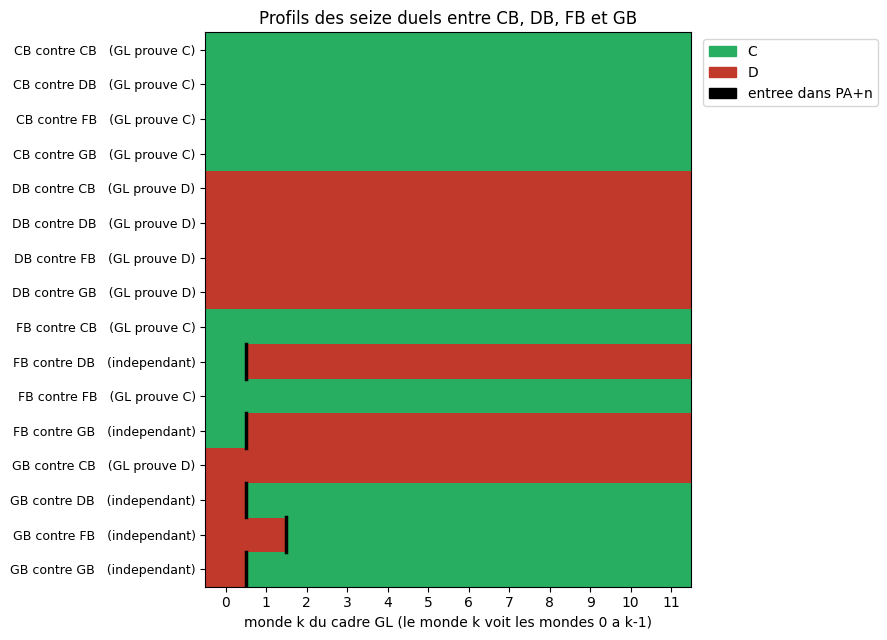

5 duels independants sur 16, niveau maximal PA+2


In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

paires = list(DUELS)
M = np.array([[1 if b else 0 for b in DUELS[p][0]] for p in paires])
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.imshow(M, cmap=ListedColormap(["#c0392b", "#27ae60"]), aspect="auto", vmin=0, vmax=1)
ax.set_yticks(range(len(paires)))
ax.set_yticklabels([f"{x} contre {y}   ({DUELS[(x, y)][1]})" for x, y in paires], fontsize=9)
ax.set_xticks(range(N_GL))
ax.set_xlabel("monde k du cadre GL (le monde k voit les mondes 0 a k-1)")
for i, p in enumerate(paires):
    niveau = DUELS[p][3]
    if niveau:
        ax.plot([niveau - 0.5] * 2, [i - 0.5, i + 0.5], color="black", lw=2.5)
ax.legend(handles=[Patch(color="#27ae60", label="C"), Patch(color="#c0392b", label="D"),
                   Patch(color="black", label="entree dans PA+n")],
          loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.set_title("Profils des seize duels entre CB, DB, FB et GB")
plt.tight_layout()
plt.show()
n_indep = sum(DUELS[p][1] == "independant" for p in paires)
print(f"{n_indep} duels independants sur {len(paires)}, "
      f"niveau maximal PA+{max(DUELS[p][3] for p in paires)}")

### Lecture de la figure

Chaque ligne est un duel, chaque colonne un monde. Le trait noir marque le monde à partir duquel le profil ne change plus, c'est-à-dire l'entrée dans la théorie $\mathsf{PA}{+}n$ qui prouve l'issue finale. Les lignes sans trait sont prouvées dès $\mathsf{PA}$. Toutes les transitions ont lieu dans les deux premiers mondes : pour ces quatre agents, les deux premières colonnes contiennent toute l'information. Le compte affiché sous la figure donne cinq duels indépendants sur seize et un niveau maximal $\mathsf{PA}{+}2$, atteint par le contrariant contre FairBot. L'exercice suivant introduit un agent qui interroge un tiers, DefectBot ; Barasz et al. lui attribuent contre CooperateBot ce même niveau $\mathsf{PA}{+}2$, atteint par un autre chemin.

### Exercice 2 — PrudentBot, et le théorème 3.2 de Barasz et al.

FairBot coopère avec CooperateBot, et laisse ainsi des gains sur la table. Barasz et al. proposent **PrudentBot** (PB), qui coopère avec $X$ si
$\mathsf{PA} \vdash [X(\mathrm{PB})]$ **et** $\mathsf{PA}{+}1 \vdash \neg[X(\mathrm{DB})]$. En logique modale :

$$[\mathrm{PB}(X)] \;\leftrightarrow\; \Box[X(\mathrm{PB})] \;\wedge\; \Box\big(\neg\Box\bot \to \neg[X(\mathrm{DB})]\big).$$

1. Écrire `PrudentBot(o)`, qui renvoie cette formule avec `Boite`, `Et`, `Non`, `Implique`, `FAUX` et `Var`.
2. L'ajouter à `AGENTS` sous le nom `"PB"` et calculer les profils de PB contre CB, DB, FB et PB, ainsi que ceux de FB contre PB.
3. Vérifier les quatre affirmations du théorème 3.2 : PB est inexploitable, coopère avec lui-même et avec FairBot, et fait défection contre CooperateBot. Relever les niveaux : Barasz et al. annoncent $\mathsf{PA}{+}1 \vdash [\mathrm{PB}(\mathrm{DB}) = D]$ et $\mathsf{PA}{+}2 \vdash [\mathrm{PB}(\mathrm{CB}) = D]$.

**Question** : pourquoi PrudentBot doit-il chercher la défection contre DefectBot dans $\mathsf{PA}{+}1$ et non dans $\mathsf{PA}$ ? Remplacer $\Box(\neg\Box\bot \to \dots)$ par $\Box(\dots)$ et observer PB contre PB.

In [13]:
# Exercice 2 : PrudentBot comme agent modal.
def PrudentBot(o):
    # TODO etudiant : renvoyer la formule de [PB(o)] (voir l'enonce).
    return None


if PrudentBot("CB") is None:
    print("Exercice 2 a completer : formule de PrudentBot.")
else:
    AGENTS["PB"] = PrudentBot
    # TODO etudiant : calculer les profils demandes avec profil() et verdict(),
    # puis confronter verdicts et niveaux au theoreme 3.2.
    print("PrudentBot enregistre ; profils a calculer.")

Exercice 2 a completer : formule de PrudentBot.


### Exercice 3 — Pourquoi PrudentBot doit interroger un tiers

PrudentBot consulte DefectBot, un **tiers** : c'est un agent de rang 1. Un agent de **rang 0** ne regarde que l'action de l'adversaire contre lui-même : sa formule est $\varphi([Y(X)])$, avec $\varphi$ modalisée. Barasz et al. (théorème 4.10) montrent qu'un tel agent ne peut pas faire mieux que FairBot face à CooperateBot : s'il coopère prouvablement avec FairBot, il coopère prouvablement avec CooperateBot.

1. Énumérer des formules $\varphi(p)$ modalisées de profondeur au plus 2, construites avec `Boite`, `Non`, `Et`, `FAUX` et la variable $p$.
2. Pour chacune, déclarer l'agent `X_i` correspondant, puis calculer ses verdicts contre FB et contre CB.
3. Vérifier que toute formule qui donne « GL prouve C » contre FB donne aussi « GL prouve C » contre CB.

**Indice** : contre CooperateBot, $[\mathrm{CB}(X)] = \top$, donc $[X(\mathrm{CB})] \leftrightarrow \varphi(\top)$. Contre FairBot, si la coopération est prouvable, alors $\Box[\mathrm{FB}(X)]$ l'est aussi.

In [14]:
# Exercice 3 : agents de rang 0, formules phi(p) ou p represente [o(X)].
# TODO etudiant : remplir la liste avec des fonctions p -> formule (modalisees en p).
FORMULES_RANG0 = []

if not FORMULES_RANG0:
    print("Exercice 3 a completer : enumerer des agents de rang 0 et tester le theoreme 4.10.")
else:
    # TODO etudiant : pour chaque phi, enregistrer l'agent dans AGENTS, calculer ses verdicts
    # contre FB et contre CB, et verifier l'implication du theoreme 4.10.
    print(len(FORMULES_RANG0), "formules a tester.")

Exercice 3 a completer : enumerer des agents de rang 0 et tester le theoreme 4.10.


## 8. Conclusion : ce qui est certifié, ce qui ne l'est pas

La règle « je coopère si je peux prouver que tu coopères » paraît circulaire. Le théorème de Löb en fait une coopération **prouvable**, et la section 3 a montré que c'est bien Löb qui tranche : sur les cadres de Kripke qui satisfont D1 à D3 mais pas Löb, l'équation de FairBot garde de nombreuses solutions.

| Niveau | Ce que ce notebook en a tiré |
|---|---|
| Témoin syntaxique (GameTheory-06e) | coopération fragile : une graphie différente de la même règle mène à $(D, D)$, et une branche morte suffit à exploiter FairBot |
| L2, `ProgramGames/FairBot.lean` | Löb est un **champ postulé** : sans autoréférence, rien ne permet de le démontrer |
| L3, `FormalLogic/FairBotLoeb.lean` | Löb est un **théorème** de FFL ; coopération avec soi et entre deux FairBots distincts, inexploitabilité, défection vraie mais non prouvable contre DefectBot, indépendance du contrariant, sans `sorryAx` ni calcul natif |
| Évaluateur modal (section 7) | les seize duels entre CB, DB, FB et GB, confrontés aux théorèmes Lean |

**Limites.**

- **Le théorème de complétude arithmétique de Solovay n'est pas formalisé.** Les verdicts « indépendant » de l'évaluateur n'ont donc de valeur, pour $\mathsf{PA}$, qu'à travers ce théorème, tel que l'utilisent Barasz et al. Seuls DefectBot et le contrariant ont un verdict négatif certifié en Lean.
- **PrudentBot n'est pas formalisé en Lean** ; ses propriétés ne sont établies ici que par l'évaluateur (exercice 2).
- **Les agents sont idéalisés** : ils décident de la prouvabilité, ce qu'aucun programme réel ne fait. Critch (2016) démontre une version bornée du théorème de Löb, où la recherche de preuve est limitée en longueur, et en déduit la coopération d'agents qui disposent de ressources finies.

**Pour aller plus loin.** Le module L3 formalise le cas du FairBot. Dans le même cadre, la section 4 de Barasz et al. classe les agents modaux par rang et montre qu'aucun agent de rang 0 ne peut à la fois coopérer prouvablement avec FairBot et faire défection contre CooperateBot (théorème 4.10, exercice 3).

## Références

- Barasz, Christiano, Fallenstein, Herreshoff, LaVictoire, Yudkowsky (2014). *Robust Cooperation in the Prisoner's Dilemma: Program Equilibrium via Provability Logic*. arXiv:1401.5577. `G:\Mon Drive\MyIA\IA\Bibliographie IA\GameTheory\2014 - Barasz et al - Robust Cooperation in the Prisoners Dilemma - Program Equilibrium via Provability Logic - arXiv 1401.5577.pdf`
- Critch (2016). *Parametric Bounded Löb's Theorem and Robust Cooperation of Bounded Agents*. arXiv:1602.04184. `G:\Mon Drive\MyIA\IA\Bibliographie IA\GameTheory\2016 - Critch - Parametric Bounded Lobs Theorem and Robust Cooperation of Bounded Agents - arXiv 1602.04184.pdf`
- Bibliothèque *Formalized Formal Logic* (paquet Lean `Foundation`), module `FirstOrder/Incompleteness/ProvabilityAbstraction`, à la révision épinglée par `formal_logic_lean/lake-manifest.json`.
- Dans ce dépôt : [GameTheory-06e](../../GameTheory/GameTheory-06e-Open-Source-Game-Theory.ipynb) (témoin syntaxique), `GameTheory/game_theory_lean/ProgramGames/FairBot.lean` (niveau L2), `formal_logic_lean/FormalLogic/FairBotLoeb.lean` (niveau L3), [Lean-34](Lean-34-Calculabilite-et-Limites.ipynb) (lemme diagonal, Gödel II, Löb).

***

**Navigation** : [<< Lean-34 (Calculabilité et limites)](Lean-34-Calculabilite-et-Limites.ipynb) | [Index](README.md) | [GameTheory-06e (transparence des programmes)](../../GameTheory/GameTheory-06e-Open-Source-Game-Theory.ipynb) | [Prolongement : Capstone Serre 100](Lean-37-Capstone-Serre100.ipynb)